[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Digdgeo/Ndvi2Gif/blob/master/workshops/ecoinformatica/notebooks/03_fenologia.ipynb)

# Fenología: cuándo despierta cada cultivo

**Taller Ndvi2Gif — Jornadas de Ecoinformática, Sevilla, 2 de octubre de 2026**

Un recuadro de 29 × 26 km a caballo del Guadalquivir, con dos paisajes agrícolas muy
distintos dentro: al norte las tablas de **arroz** de Isla Mayor y Los Palacios, que se
inundan en primavera y se cosechan en septiembre; al sur y al este, sobre marisma
colonizada, el **mosaico de Lebrija y Las Cabezas** — algodón, girasol, remolacha,
hortícolas, regadío y secano mezclados parcela a parcela.

Dos fenologías en la misma imagen es lo mejor que le puede pasar a este notebook, porque lo
que hace `SpatialPhenologyAnalyzer` es precisamente **sacar fechas** píxel a píxel de una
serie de compuestos, y aquí las fechas cambian de una parcela a la de al lado.

Cuatro métricas, y todas en día del año (DOY):

| sigla | qué es |
|---|---|
| **SOS** | *start of season*, el arranque |
| **POS** | *peak of season*, el máximo |
| **EOS** | *end of season*, el final |
| **LOS** | *length of season*, EOS − SOS |

In [1]:
# !pip install -q ndvi2gif

import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ndvi2gif import NdviSeasonality, SpatialPhenologyAnalyzer

# ee.Authenticate()        # solo la primera vez
PROJECT = 'tu-proyecto-de-earth-engine'
ee.Initialize(project=PROJECT)
print('✓ Earth Engine listo')

DOY_VIS = {'min': 60, 'max': 330,
           'palette': ['#2c7bb6', '#abd9e9', '#ffffbf', '#fdae61', '#d7191c']}
LOS_VIS = {'min': 60, 'max': 240, 'palette': ['#ffffcc', '#78c679', '#006837']}

/home/diego/miniconda3/envs/ndvi2gif_clean/lib/python3.9/site-packages/geemap/conversion.py:23: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


✓ Earth Engine listo


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


## 1. La zona

En color natural y en pleno julio se ven los dos paisajes de un vistazo. Arriba, las tablas
de arroz: bloques grandes y de un verde muy oscuro, con los canales marcando la cuadrícula
y alguna tabla en barbecho clarísima al lado. Abajo a la derecha, el mosaico: parcelas
pequeñas, cada una de un tono, porque cada cultivo va por su sitio del calendario.

In [2]:
roi = ee.Geometry.Rectangle([-6.25, 36.95, -5.92, 37.18])
print('ROI: %.0f km²' % (roi.area(100).getInfo() / 1e6))

verano = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
          .filterBounds(roi).filterDate('2021-07-01', '2021-08-31')
          .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10)).median().clip(roi))

Mapa = geemap.Map()
Mapa.centerObject(roi, 11)
Mapa.addLayer(verano, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 2500},
              'Color natural, julio de 2021')
Mapa

ROI: 749 km²


Map(center=[37.065056147633236, -6.084999999999495], controls=(WidgetControl(options=['position', 'transparent…

## 2. Doce compuestos al año

La fenología necesita resolución temporal, así que aquí `periods=12` (un compuesto por mes)
y `key='median'`, que es el reductor honesto: el máximo mensual se contamina con cualquier
píxel raro y adelanta artificialmente el arranque de la estación.

`SpatialPhenologyAnalyzer` se monta sobre el `NdviSeasonality`, igual que el analizador de
hidroperiodo.

In [3]:
procesador = NdviSeasonality(roi=roi, periods=12, start_year=2019, end_year=2022,
                             sat='S2', index='ndvi', key='median')
pheno = SpatialPhenologyAnalyzer(procesador)

There we go again...
Applying cloud filter to Sentinel-2: max 20% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering


## 3. La estación típica

`phenology_summary()` resume los cuatro años en un solo mapa por métrica: la fenología
mediana del arrozal. Azul = temprano, rojo = tardío.

In [4]:
resumen = pheno.phenology_summary(method='threshold', reducer='median')
print('bandas:', resumen.bandNames().getInfo())

MapaPheno = geemap.Map()
MapaPheno.centerObject(roi, 11)
MapaPheno.add_basemap('SATELLITE')
for banda, vis, titulo in [('sos', DOY_VIS, 'SOS — arranque'),
                           ('pos', DOY_VIS, 'POS — máximo'),
                           ('eos', DOY_VIS, 'EOS — final'),
                           ('los', LOS_VIS, 'LOS — duración')]:
    MapaPheno.addLayer(resumen.select(banda), vis, titulo, shown=banda == 'sos')
MapaPheno.add_colorbar(DOY_VIS, label='día del año  (azul = temprano, rojo = tardío)',
                       orientation='horizontal')
MapaPheno

bandas: ['sos', 'pos', 'eos', 'los', 'amplitude', 'peak_value', 'baseline', 'growth_rate', 'senescence_rate']


Map(center=[37.065056147633236, -6.084999999999495], controls=(WidgetControl(options=['position', 'transparent…

In [5]:
METRICAS = ['sos', 'pos', 'eos', 'los', 'amplitude']
valores = resumen.select(METRICAS).reduceRegion(
    reducer=ee.Reducer.median().combine(ee.Reducer.percentile([10, 90]),
                                        sharedInputs=True),
    geometry=roi, scale=60, maxPixels=1e9, bestEffort=True, tileScale=4).getInfo()

tabla = pd.DataFrame({'p10': {m: valores[m + '_p10'] for m in METRICAS},
                      'mediana': {m: valores[m + '_median'] for m in METRICAS},
                      'p90': {m: valores[m + '_p90'] for m in METRICAS}})
tabla.round(1)

,p10,mediana,p90
sos,16.0,120.9,197.2
pos,90.2,212.6,243.4
eos,166.5,258.2,304.3
los,46.1,76.5,212.9
amplitude,0.3,0.6,0.9


Mira la fila del SOS antes que nada: p10 en el **día 16**, mediana en el **121** y p90 en el
**197**. Entre el primer decil y el último hay **seis meses**. Eso no es un cultivo con una
fecha de arranque: son muchos cultivos distintos dentro del mismo recuadro, y la mediana del
conjunto —mediados de abril— no describe a casi ningún píxel.

La amplitud, en cambio, sí es uniforme (mediana 0,6): casi todo el recuadro es tierra de
labor que pasa de suelo desnudo a dosel cerrado. Hay estación en todas partes; lo que cambia
es cuándo.

Y esa es la señal de que hay que separar las dos zonas.

### Dos paisajes, dos calendarios

Aquí no hay número que valga. El arrozal es un cultivo uniforme pero su caja lleva dentro
barbechos, canales y caminos, y el mosaico de Lebrija es por definición lo contrario de un
promedio: algodón, girasol, remolacha y hortícolas en parcelas contiguas. Una mediana
describiría a muy pocos píxeles de cualquiera de las dos.

Lo que hay que mirar es el mapa — y si hace falta un número, la **distribución entera**, que
no es lo mismo que su centro.

In [6]:
ZONAS = {'arroz (Isla Mayor)': ee.Geometry.Rectangle([-6.22, 37.05, -5.98, 37.17]),
         'mosaico (Lebrija)': ee.Geometry.Rectangle([-6.08, 36.96, -5.93, 37.04])}

MapaZonas = geemap.Map()
MapaZonas.centerObject(roi, 11)
MapaZonas.addLayer(resumen.select('sos'), DOY_VIS, 'SOS — arranque de estación')
for nombre, geometria in ZONAS.items():
    MapaZonas.addLayer(ee.Image().byte().paint(
        ee.FeatureCollection([ee.Feature(geometria)]), 1, 2),
        {'palette': ['000000']}, nombre)
MapaZonas.add_colorbar(DOY_VIS, label='SOS (día del año)', orientation='horizontal')
MapaZonas

Map(center=[37.065056147633236, -6.084999999999495], controls=(WidgetControl(options=['position', 'transparent…

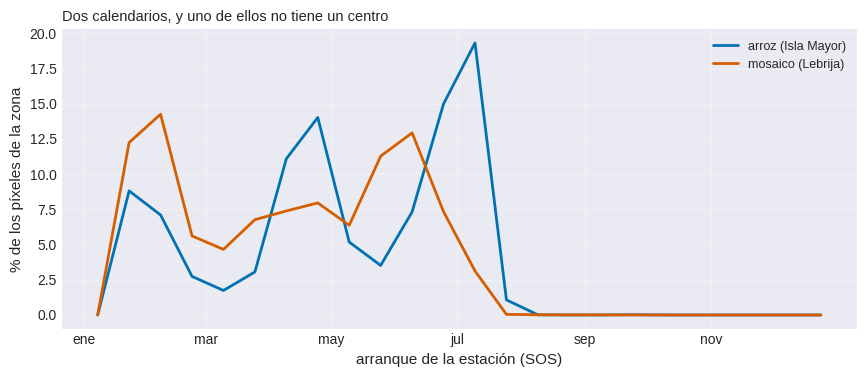

In [7]:
# ni media ni desviación: la distribución entera del arranque de estación en cada zona
hist = ee.Dictionary({
    nombre: resumen.select('sos').reduceRegion(
        ee.Reducer.fixedHistogram(0, 366, 24), geometria, 60, maxPixels=1e9,
        bestEffort=True, tileScale=4).get('sos')
    for nombre, geometria in ZONAS.items()}).getInfo()

fig, ax = plt.subplots(figsize=(8.8, 3.9))
for nombre, color in zip(ZONAS, ['#0072B2', '#D55E00']):
    datos = np.array(hist[nombre])
    ax.plot(datos[:, 0] + 7.6, 100 * datos[:, 1] / datos[:, 1].sum(), lw=2,
            color=color, label=nombre)
ax.set_xticks([1, 60, 121, 182, 244, 305])
ax.set_xticklabels(['ene', 'mar', 'may', 'jul', 'sep', 'nov'])
ax.set_xlabel('arranque de la estación (SOS)')
ax.set_ylabel('% de los píxeles de la zona')
ax.set_title('Dos calendarios, y uno de ellos no tiene un centro', loc='left',
             fontsize=10.5)
ax.legend(frameon=False, fontsize=9)
for lado in ('top', 'right'):
    ax.spines[lado].set_visible(False)
plt.tight_layout()
plt.show()

En el mapa de arriba, con los dos recuadros encima, la historia se cuenta sola: el arrozal
es una mancha grande y homogénea —parcelas enormes que arrancan todas a la vez— y el mosaico
es un confeti donde cada parcela tiene su color, es decir, su fecha. Acércate a los dos y
compáralos.

El histograma le pone número a eso sin recurrir a un promedio. El arroz concentra **un
tercio de sus píxeles entre el 17 de junio y el 17 de julio**, en dos intervalos seguidos:
un pico único y tardío, el de un cultivo que se siembra sobre lámina de agua en mayo y
cierra el dosel en pleno verano. El mosaico tiene **dos modas**: una entre mediados de enero
y mediados de febrero, con el 26 % de sus píxeles, y otra a primeros de junio. Son los
cultivos de invierno y los de primavera-verano conviviendo parcela con parcela.

Por eso la mediana del mosaico cae en abril, que es justo **el valle entre sus dos modas**:
el día del año en que menos parcelas arrancan. Un promedio de una distribución con dos picos
señala el hueco que hay entre ellos.

## 4. Tres métodos y tres respuestas

"Cuándo empieza la estación" no tiene una sola definición. La librería trae tres:

- **`threshold`** — el día en que el NDVI pasa un porcentaje de la amplitud del año
  (por defecto el 20 %). Es el estándar de la bibliografía de fenología de satélite.
- **`derivative`** — el día de máxima pendiente, el momento de crecimiento más rápido.
- **`harmonic`** — se ajusta una curva de senos y cosenos al año y se fechan sus puntos
  notables. Suaviza mucho, y ahí está su problema.

In [8]:
METODOS = ['threshold', 'derivative', 'harmonic']
sos = {m: pheno.phenology_summary(method=m).select('sos') for m in METODOS}

filas = {}
for m, imagen in sos.items():
    filas[m] = imagen.reduceRegion(
        reducer=ee.Reducer.median().combine(ee.Reducer.stdDev(), sharedInputs=True),
        geometry=roi, scale=60, maxPixels=1e9, bestEffort=True, tileScale=4).getInfo()

pd.DataFrame({'SOS mediano (DOY)': {m: filas[m]['sos_median'] for m in METODOS},
              'dispersión (desv. típica, días)': {m: filas[m]['sos_stdDev']
                                                  for m in METODOS}}).round(1)

,SOS mediano (DOY),"dispersión (desv. típica, días)"
threshold,120.9,63.5
derivative,181.5,62.4
harmonic,86.0,55.2


In [9]:
MapaMetodos = geemap.Map()
MapaMetodos.centerObject(roi, 11)
for metodo in METODOS:
    MapaMetodos.addLayer(sos[metodo], DOY_VIS, 'SOS — %s' % metodo,
                         shown=metodo == 'threshold')
MapaMetodos.add_colorbar(DOY_VIS, label='SOS (día del año)', orientation='horizontal')
MapaMetodos

Map(center=[37.065056147633236, -6.084999999999495], controls=(WidgetControl(options=['position', 'transparent…

El armónico sale **antes** que los otros dos, y no es un error del código: con dos
armónicos la curva no puede subir tan rápido como sube de verdad un cultivo de regadío que
pasa de suelo desnudo a dosel cerrado en seis semanas, así que coloca el arranque y el
máximo demasiado pronto. La solución es darle más armónicos.

In [10]:
prueba = []
for n in [2, 3, 4]:
    imagen = pheno.phenology_summary(method='harmonic', n_harmonics=n)
    v = imagen.select(['sos', 'pos', 'eos', 'los']).reduceRegion(
        ee.Reducer.median(), roi, scale=60, maxPixels=1e9, bestEffort=True,
        tileScale=4).getInfo()
    prueba.append({'n_harmonics': n, **{k: v[k] for k in ['sos', 'pos', 'eos', 'los']}})

print('para comparar, método del umbral: SOS %.0f, POS %.0f'
      % (filas['threshold']['sos_median'], tabla.loc['pos', 'mediana']))
pd.DataFrame(prueba).set_index('n_harmonics').round(0)

para comparar, método del umbral: SOS 121, POS 213


,sos,pos,eos,los
n_harmonics,,,,
2,86.0,191.0,266.0,115.0
3,96.0,206.0,261.0,100.0
4,86.0,206.0,261.0,115.0


## 5. Año a año: los años en que el arroz no ocurrió

Hasta aquí todo eran medianas de cuatro años. `extract_phenology_rasters()` da un ráster
por año, y es donde aparece lo interesante — porque estos fueron años de sequía, y en el
Guadalquivir una sequía no reparte igual: el arroz depende de que le asignen agua, y hubo
años en que **se recortó la superficie sembrada** hasta casi hacerla desaparecer, mientras
el regadío del mosaico seguía con lo suyo.

El filtro es la amplitud: por debajo de 0,3 de recorrido de NDVI, ese píxel no tuvo
estación y su SOS es ruido.

In [11]:
anuales = pheno.extract_phenology_rasters(method='threshold')
anios = list(range(procesador.start_year, procesador.end_year + 1))
print('%d imágenes, una por año' % anuales.size().getInfo())

AMPLITUD = 0.3        # por debajo de esto el píxel no tuvo estación

por_anio = []
for anio in anios:
    imagen = ee.Image(anuales.filter(ee.Filter.eq('year', anio)).first())
    estacional = imagen.updateMask(imagen.select('amplitude').gte(AMPLITUD))
    fechas = estacional.select(['sos', 'eos', 'los']).reduceRegion(
        ee.Reducer.median(), roi, scale=60, maxPixels=1e9, bestEffort=True,
        tileScale=4).getInfo()
    # mask().mean() sobre una región es la fracción de píxeles que pasan el filtro:
    # en todo el recuadro y, por separado, en cada una de las dos zonas
    con_estacion = imagen.select('amplitude').gte(AMPLITUD)
    partes = ee.Dictionary({
        nombre: con_estacion.reduceRegion(ee.Reducer.mean(), geometria, 60,
                                          maxPixels=1e9, bestEffort=True,
                                          tileScale=4).values().get(0)
        for nombre, geometria in [('recuadro', roi)] + list(ZONAS.items())}).getInfo()
    por_anio.append({'año': anio, **{k: fechas[k] for k in ['sos', 'eos', 'los']},
                     'con estación': partes['recuadro'],
                     'solo arrozal': partes['arroz (Isla Mayor)'],
                     'solo mosaico': partes['mosaico (Lebrija)']})

por_anio = pd.DataFrame(por_anio).set_index('año')
por_anio.round(2)

4 imágenes, una por año


,sos,eos,los,con estación,solo arrozal,solo mosaico
año,,,,,,
2019,166.0,258.0,60.96,0.87,0.92,0.82
2020,198.0,259.0,91.92,0.89,0.94,0.84
2021,45.0,228.0,62.00,0.77,0.69,0.82
2022,136.0,258.0,60.90,0.55,0.43,0.69


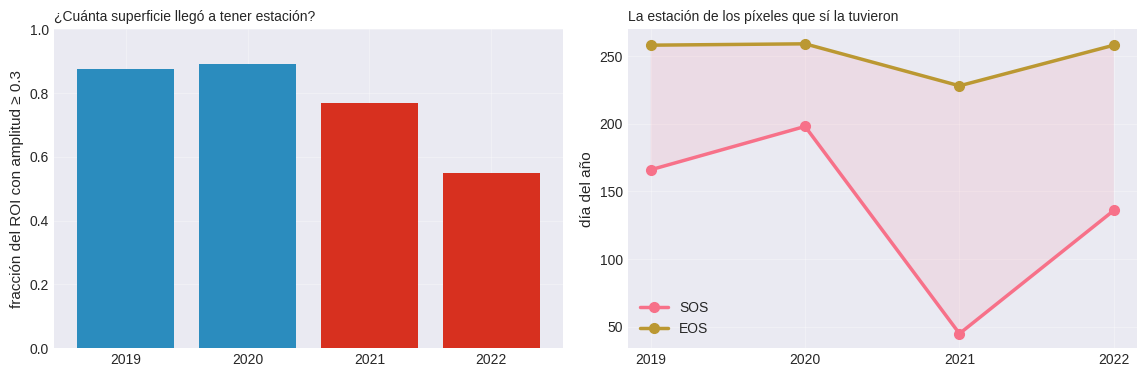

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11.6, 3.9))
axes[0].bar(por_anio.index.astype(str), por_anio['con estación'],
            color=['#2b8cbe' if v > 0.8 else '#d7301f'
                   for v in por_anio['con estación']])
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('fracción del ROI con amplitud ≥ %.1f' % AMPLITUD)
axes[0].set_title('¿Cuánta superficie llegó a tener estación?', loc='left', fontsize=10)

axes[1].plot(por_anio.index, por_anio['sos'], 'o-', label='SOS')
axes[1].plot(por_anio.index, por_anio['eos'], 'o-', label='EOS')
axes[1].fill_between(por_anio.index, por_anio['sos'], por_anio['eos'], alpha=0.12)
axes[1].set_ylabel('día del año')
axes[1].set_xticks(por_anio.index)
axes[1].set_title('La estación de los píxeles que sí la tuvieron', loc='left', fontsize=10)
axes[1].legend(frameon=False)

for ax in axes:
    for lado in ('top', 'right'):
        ax.spines[lado].set_visible(False)
plt.tight_layout()
plt.show()

In [13]:
MapaAnios = geemap.Map()
MapaAnios.centerObject(roi, 11)
for anio in anios:
    imagen = ee.Image(anuales.filter(ee.Filter.eq('year', anio)).first())
    MapaAnios.addLayer(imagen.select('sos'), DOY_VIS,
                       'SOS %d  (%.0f %% con estación)'
                       % (anio, 100 * por_anio.loc[anio, 'con estación']),
                       shown=anio == anios[-1])
MapaAnios.add_colorbar(DOY_VIS, label='SOS (día del año)', orientation='horizontal')
MapaAnios

Map(center=[37.065056147633236, -6.084999999999495], controls=(WidgetControl(options=['position', 'transparent…

Y aquí está la lección que no es de fenología sino de interpretación. La superficie con
estación se desploma: **87 % en 2019 y 89 % en 2020, 77 % en 2021 y 55 % en 2022**. Pero el
desplome no es del recuadro entero, es **del arrozal**: mira las dos últimas columnas. La
zona del arroz pasa del 94 % al **43 %**, mientras el mosaico de Lebrija solo baja del 84 %
al 69 % — y en 2021 ni se entera, con un 82 % que es su valor de siempre.

Es lo que cabe esperar de una sequía en el Guadalquivir. El arroz depende de que le asignen
agua y hubo años de recorte casi total; el regadío del mosaico siguió sembrando. Así que lo
que el mapa de SOS enseña en 2022 **no es un arroz más tardío: es que no hubo arroz** en más
de la mitad de las tablas, y quien no conozca la zona leerá "cambio fenológico" donde hubo
una decisión administrativa.

Por eso la amplitud va siempre al lado de las fechas. Sin ella, el SOS mediano de 2021 —día
45, mediados de febrero— parecería un adelanto espectacular de la estación, cuando lo que
está fechando es la vegetación espontánea de las tablas que se quedaron sin sembrar.

## 6. Tu zona, tu GeoTIFF

Ahora te toca. Dibuja en el mapa un polígono **pequeño** —una o dos parcelas del mosaico,
un par de kilómetros cuadrados como mucho— con la barra de herramientas de la izquierda.
Cada uno la suya: no hay dos parcelas con el mismo calendario, que es justo la gracia.

Con eso calculamos su fenología y la bajamos como GeoTIFF para abrirla en QGIS.

In [14]:
MapaDibujo = geemap.Map(center=[37.02, -6.02], zoom=12)
MapaDibujo.add_basemap('SATELLITE')
MapaDibujo

Map(center=[37.02, -6.02], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGU…

In [15]:
mi_zona = MapaDibujo.user_roi
if mi_zona is None:
    # por si ejecutas el notebook de un tirón: un trozo del mosaico de Lebrija
    mi_zona = ee.Geometry.Rectangle([-6.04, 36.99, -6.01, 37.01])
    print('no hay nada dibujado, uso un recuadro de ejemplo')
print('tu zona: %.1f km²' % (mi_zona.area(10).getInfo() / 1e6))

mi_pheno = SpatialPhenologyAnalyzer(
    NdviSeasonality(roi=mi_zona, periods=12, start_year=2019, end_year=2022,
                    sat='S2', index='ndvi', key='median'))

# export=True escribe el GeoTIFF en el directorio de trabajo, con los nombres de las
# bandas dentro del fichero. A 20 m y un par de km² la descarga directa va sobrada;
# para áreas grandes hay que usar export_target='drive'
mi_resumen = mi_pheno.phenology_summary(method='threshold', reducer='median',
                                        export=True, export_target='local', scale=20)

no hay nada dibujado, uso un recuadro de ejemplo
tu zona: 5.9 km²
There we go again...
Applying cloud filter to Sentinel-2: max 20% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering


Exporting S2_ndvi_phenology_threshold_median_2019_2022.tif
Generating URL ...


Please wait ...


Data downloaded to /tmp/claude-1000/-home-diego-git-Ndvi2Gif/058151fe-0128-43aa-8abd-f2684877e860/scratchpad/S2_ndvi_phenology_threshold_median_2019_2022.tif
Image have been exported


In [16]:
FICHERO = 'S2_ndvi_phenology_threshold_median_2019_2022.tif'

try:                                    # en Colab, al ordenador del alumno
    from google.colab import files
    files.download(FICHERO)
except ImportError:                     # en local, ya está en disco
    import os
    print('escrito en', os.path.join(os.getcwd(), FICHERO))

escrito en /tmp/claude-1000/-home-diego-git-Ndvi2Gif/058151fe-0128-43aa-8abd-f2684877e860/scratchpad/S2_ndvi_phenology_threshold_median_2019_2022.tif


Ábrelo en **QGIS** (o en Geolibre) y verás nueve bandas con su nombre puesto: `sos`, `pos`,
`eos`, `los`, `amplitude`, `peak_value`, `baseline`, `growth_rate` y `senescence_rate`.

Dos cosas para que se vea bien a la primera:

- carga la banda `sos` sola, con una rampa de color y el rango ajustado a tus datos
  (botón derecho → *Propiedades* → *Simbología* → *Banda única pseudocolor*);
- y pon debajo la ortofoto del PNOA, que es cuando se entiende: cada parcela es de un color
  porque cada una se sembró su día.

## 7. Sacarlo todo de golpe

Las dos funciones exportan directamente, a local o a Drive:

```python
# un GeoTIFF con las métricas medianas
pheno.phenology_summary(method='harmonic', reducer='median',
                        export=True, export_target='local', scale=20)

# un GeoTIFF por año, a Drive (mejor para áreas grandes)
pheno.extract_phenology_rasters(method='harmonic', export=True,
                                export_target='drive',
                                drive_folder='ndvi2gif_fenologia', scale=20)
```

## Las perillas que importan

| parámetro | qué hace |
|---|---|
| `periods` | resolución temporal. Con menos de 12 no hay fenología que sacar |
| `key` | `'median'` para fenología; `'max'` adelanta el arranque |
| `method` | `threshold`, `derivative` o `harmonic` |
| `n_harmonics` | 2 suaviza de más en cultivos; 3 va mejor |
| `amplitude` | el filtro de "aquí no hubo estación" |

- El libro, con la versión larga: **https://digdgeo.github.io/Ndvi2Gif/**
- Y los dos notebooks anteriores del taller: `01_rois_y_estadisticos.ipynb` y
  `02_hidroperiodo.ipynb`.